## Part 1: Data Exploration and Visualization
In this section, we load the raw dataset and extract basic information such as the number of records, features, and target variable to meet the project requirements. We also identify missing values and create visualizations to understand the main reasons behind customer churn.

Importing Libraries

In [1]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for graphs
sns.set_theme(style="whitegrid")

Loading Data and Extracting Dataset Info

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw_data.csv')

# Print dataset information based on assignment requirements
print("--- DATASET OVERVIEW ---")
print("1. Dataset source: IBM Telco Customer Churn (Kaggle)")
print(f"2. Number of records: {df.shape[0]}")
print(f"3. Number of features: {df.shape[1]}")
print("4. Target variable: 'Churn' (Yes/No)")
print("5. Feature descriptions: Contains demographic info, account info, and services.")

print("\n--- DATA TYPES ---")
print(df.dtypes)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print(f"\n--- DUPLICATE RECORDS ---")
print(f"Number of duplicates: {df.duplicated().sum()}")

# Identify hidden data quality issues
blank_spaces = len(df[df['TotalCharges'] == " "])
print(f"\n--- DATA QUALITY ISSUES ---")
print(f"Found {blank_spaces} blank spaces in 'TotalCharges' column.")

--- DATASET OVERVIEW ---
1. Dataset source: IBM Telco Customer Churn (Kaggle)
2. Number of records: 7043
3. Number of features: 21
4. Target variable: 'Churn' (Yes/No)
5. Feature descriptions: Contains demographic info, account info, and services.

--- DATA TYPES ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

--- MISSING VALUES ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents        

Data Visualization

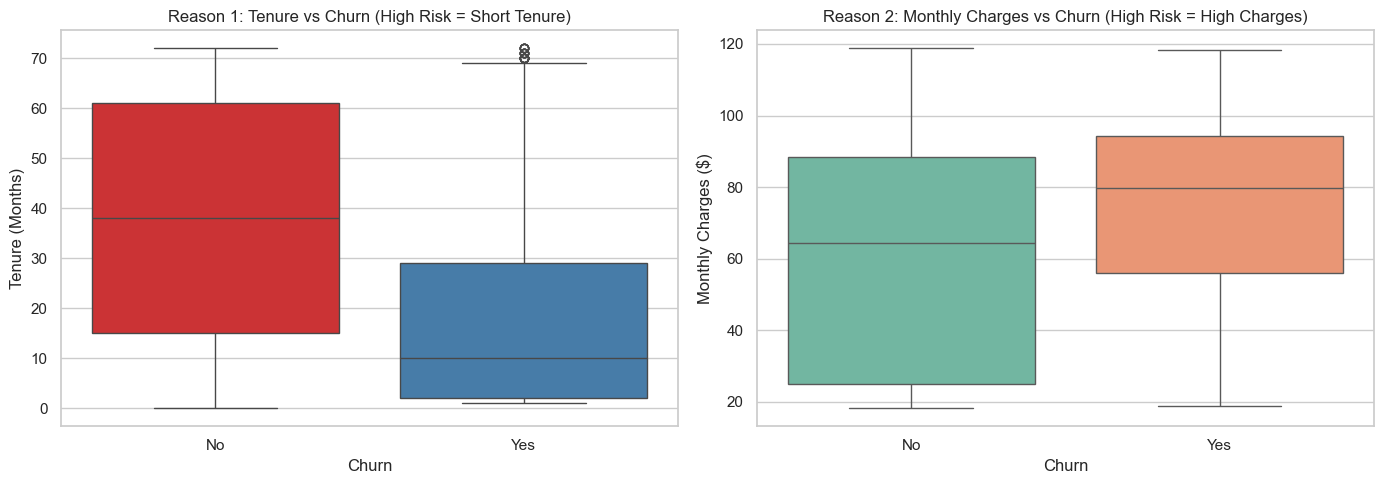

In [3]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0], palette='Set1', hue='Churn', legend=False)
axes[0].set_title('Reason 1: Tenure vs Churn (High Risk = Short Tenure)')
axes[0].set_ylabel('Tenure (Months)')

# Graph 2: Monthly Charges vs Churn
# Convert TotalCharges to numeric safely before plotting
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1], palette='Set2', hue='Churn', legend=False)
axes[1].set_title('Reason 2: Monthly Charges vs Churn (High Risk = High Charges)')
axes[1].set_ylabel('Monthly Charges ($)')

# Adjust layout and display the graphs
plt.tight_layout()
plt.show()

## Part 2: Data Preprocessing and Feature Engineering
Before training the model, we need to clean and format our data. We apply meaningful feature engineering techniques: handling missing values, dropping irrelevant columns, creating new features, encoding categorical data into numbers, and scaling numerical values.

Handling Missing Values and Dropping Features

In [4]:
# Technique 1: Handle missing values in TotalCharges
# Convert text to numbers. Empty strings will become NaN (Not a Number).
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count and print the number of missing values
missing_count = df['TotalCharges'].isnull().sum()
print(f"Missing values found in 'TotalCharges': {missing_count}")

# Fill all NaN values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("All missing values have been successfully filled with 0.\n")

# Technique 2: Remove irrelevant features
# Drop the customerID column because it is not needed for the ML model
df = df.drop('customerID', axis=1)
print("The 'customerID' column has been successfully removed.")

Missing values found in 'TotalCharges': 11
All missing values have been successfully filled with 0.

The 'customerID' column has been successfully removed.


Feature Creation and Encoding

In [5]:
# Technique 3: Create a new feature (Tenure in Years)
df['TenureInYears'] = df['tenure'] / 12.0

# Technique 4: Encode categorical variables into numbers
# Map binary categories
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Use One-Hot Encoding for multi-class categories
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

# Technique 5: Standardize numerical features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TenureInYears']

df[num_cols] = scaler.fit_transform(df[num_cols])

print("Data Preprocessing Completed. Shape of new dataframe:", df.shape)

Data Preprocessing Completed. Shape of new dataframe: (7043, 32)


## Part 3: Model Training, Evaluation, and Serialization
In this final step, we separate our target variable and split the dataset into training and testing sets. We train a Random Forest Classifier, evaluate its accuracy, and finally save the model and scaler as `.pkl` files for the backend application.

Train-Test Split and Model Training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Separate features (X) and target variable (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Model Training Completed Successfully!")

Random Forest Model Training Completed Successfully!


Model Evaluation

In [8]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the testing set
y_pred = rf_model.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Print detailed classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 79.28%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Saving the Model

In [9]:
import joblib
import os

# Create directory if it does not exist
os.makedirs('../models', exist_ok=True)

# Save the trained model and scaler
joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and Scaler successfully saved as .pkl files!")

Model and Scaler successfully saved as .pkl files!


## Part 4: Model Explainability with SHAP
To understand how our Random Forest model makes decisions, we use SHAP (SHapley Additive exPlanations). This helps us see which features have the biggest impact on predicting whether a customer will churn or stay.

--- SHAP Summary Plot: Feature Impact on Customer Churn ---


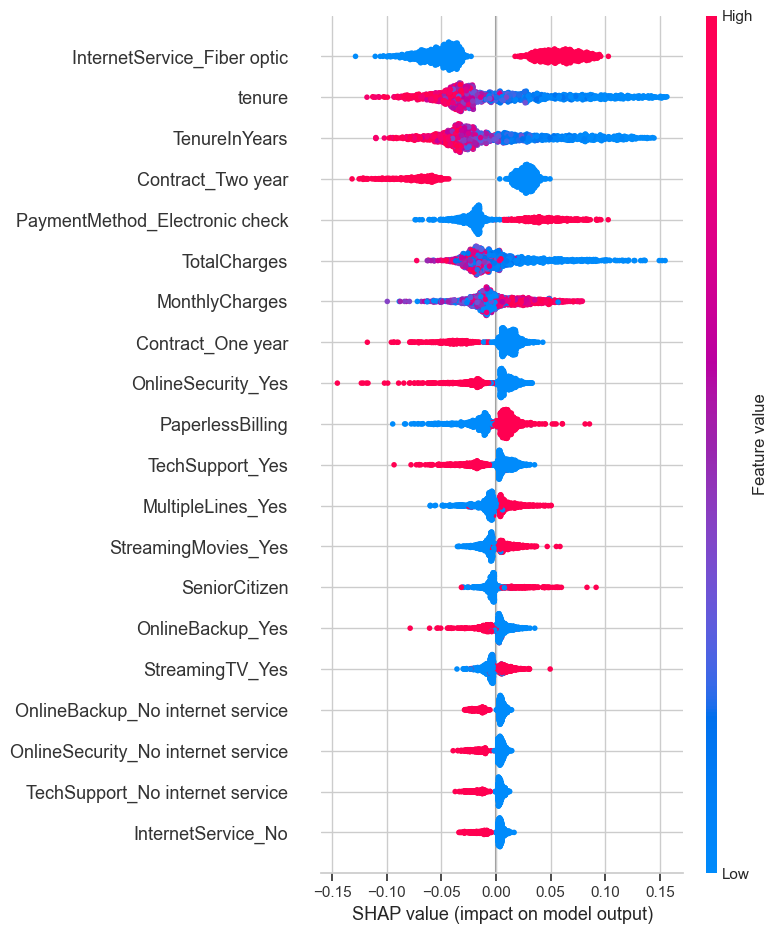


--- SHAP Feature Importance (Bar Plot) ---


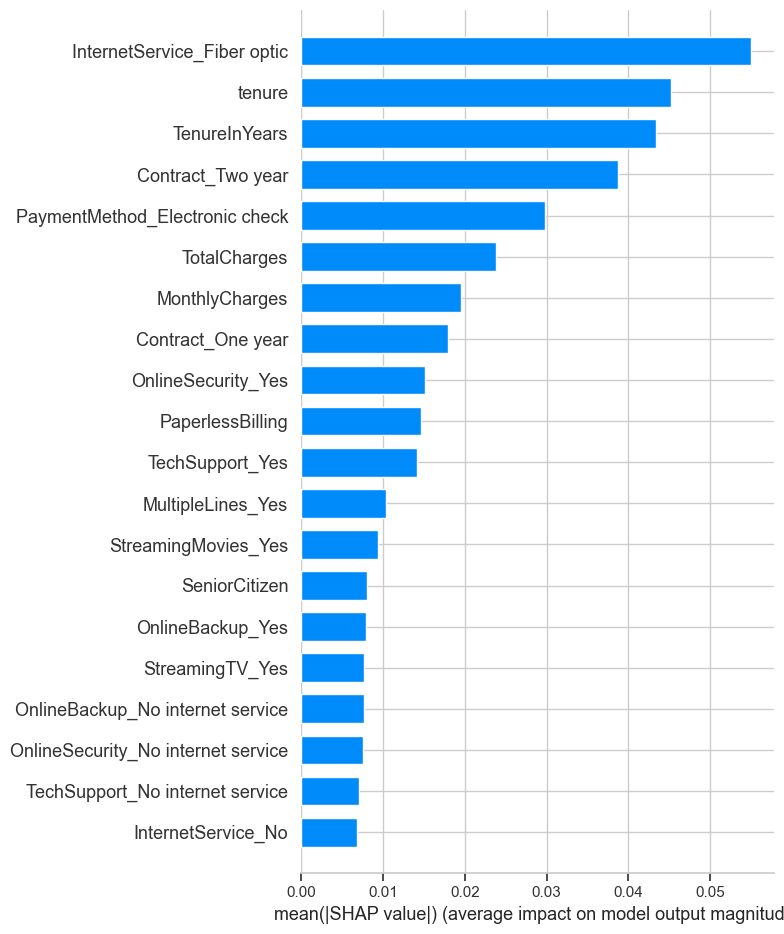

In [10]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the SHAP TreeExplainer with our trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test)

# Handle different SHAP library versions
# Older versions return a list, newer versions return a 3D numpy array
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    # 3D array shape is (samples, features, classes), we want class 1 (Churn = Yes)
    shap_values_pos = shap_values[:, :, 1]

# 3. Generate a Summary Plot
print("--- SHAP Summary Plot: Feature Impact on Customer Churn ---")
shap.summary_plot(shap_values_pos, X_test, show=False)

# Adjust layout and display the plot safely
plt.tight_layout()
plt.show()

# 4. Feature Importance Bar Plot (Alternative simple view)
print("\n--- SHAP Feature Importance (Bar Plot) ---")
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()